# Frobenius Group of Order 21: Spherical Training with Unshared Embedding

This notebook demonstrates Stage 1 training on the **Frobenius group G = C_7 ⋊ C_3** with **unshared embedding** (`share_embed=False`).

**Task**: Group multiplication (g, h) → g·h (non-commutative)

**Group**: G = C_7 ⋊ C_3 (unique non-abelian group of order 21)
- Elements: pairs (a, b) where a ∈ {1, 2, 4} ⊂ Z_7* and b ∈ Z_7
- Multiplication: (a, b) · (a', b') = (a·a' mod 7, b + a·b' mod 7)

**Basis**: 5 irreducible representations:
- trivial (1D): ρ(g) = 1
- omega (1D): ρ(a,b) = ω^k where a = 2^k, ω = e^(2πi/3)
- omega_conj (1D): conjugate of omega
- rho_3 (3D): constructed from generators
- rho_3_conj (3D): complex conjugate of rho_3

**Key feature**: Both 1D (omega/omega_conj) and 3D (rho_3/rho_3_conj) irreps form **non-self-conjugate pairs**.

In [256]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter

from src.tasks import Frobenius21Multiplication
from src.basis import Frobenius21Basis
from src.model import WideNetworkScaleSphere
from src.utils import cross_entropy_high_precision, accuracy, project_gradient_to_tangent_space, normalize_to_pi
from src.frobenius_analysis import d_sim, extract_irrep_matrices, compute_irrep_energy, compute_grouped_energy, compute_sv_ratio
from src.plotting import (setup_plot_style, make_blue_white_red_cmap,
                          get_frobenius_display_info, scale_by_sqrt_d,
                          plot_dft_bars, plot_dft_heatmap, FROBENIUS21_IRREP_LATEX)

setup_plot_style()
blue_white_red = make_blue_white_red_cmap()

## 1. Configuration

In [257]:
WIDTH = 512
ACT_TYPE = 'Quad'
INIT_SCALE = 0.5
SHARE_EMBED = False

LR = 0.5
NUM_EPOCHS = 10000
PRINT_EVERY = 500
TRACK_EVERY = 10

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cpu')
vocab_size = 21

print(f"Frobenius Group: G = C_7 ⋊ C_3, |G| = {vocab_size}")
print(f"Model: width={WIDTH}, act={ACT_TYPE}, share_embed={SHARE_EMBED}")

Frobenius Group: G = C_7 ⋊ C_3, |G| = 21
Model: width=512, act=Quad, share_embed=False


## 2. Initialize Task, Basis, and Model

In [258]:
# Create task and basis
task = Frobenius21Multiplication()
basis = Frobenius21Basis()

print(f"Task: {task}")
print(f"Basis: {basis}")
print(f"\nIrreducible representations (label -> dimension):")
for label, dim in basis.irrep_dimensions.items():
    print(f"  {label}: dim = {dim} -> contributes {dim**2} basis functions")
print(f"\nTotal basis functions: {sum(d**2 for d in basis.irrep_dimensions.values())} = {vocab_size}")
print(f"\nConjugate pairs:")
print(f"  - omega & omega_conj (both 1D)")
print(f"  - rho_3 & rho_3_conj (both 3D)")

Task: Frobenius21Multiplication(vocab_size=21)
Basis: Frobenius21Basis(size=21, irreps={trivial:1, omega:1, omega_conj:1, rho_3:3, rho_3_conj:3})

Irreducible representations (label -> dimension):
  trivial: dim = 1 -> contributes 1 basis functions
  omega: dim = 1 -> contributes 1 basis functions
  omega_conj: dim = 1 -> contributes 1 basis functions
  rho_3: dim = 3 -> contributes 9 basis functions
  rho_3_conj: dim = 3 -> contributes 9 basis functions

Total basis functions: 21 = 21

Conjugate pairs:
  - omega & omega_conj (both 1D)
  - rho_3 & rho_3_conj (both 3D)


In [259]:
# Generate data
data, labels = task.generate_all_data(device)

# Create model
model = WideNetworkScaleSphere(
    d_vocab=vocab_size,
    width=WIDTH,
    act_type=ACT_TYPE,
    init_scale=INIT_SCALE,
    share_embed=SHARE_EMBED,
).to(device)

print(f"\nModel architecture:")
print(f"  W_in:  {model.W_in.shape}  <- (width, 2*vocab_size) for unshared")
print(f"  W_out: {model.W_out.shape}")
print(f"  scale_in:  {model.scale_in.item():.4f}")
print(f"  scale_out: {model.scale_out.item():.4f}")
print(f"\nDataset: {len(data)} samples")


Model architecture:
  W_in:  torch.Size([512, 42])  <- (width, 2*vocab_size) for unshared
  W_out: torch.Size([21, 512])
  scale_in:  0.5000
  scale_out: 0.5000

Dataset: 441 samples


## 3. Run Stage 1 Training (Projected GD on Sphere)

In [260]:
W_in_init = model.W_in.detach().cpu().clone()
W_out_init = model.W_out.detach().cpu().clone()

model.scale_in.requires_grad = False
model.scale_out.requires_grad = False
optimizer = optim.SGD([model.W_in, model.W_out], lr=LR)

losses = []
accuracies = []

def compute_all_metrics_at_epoch(model_obj, basis_obj, vocab_sz):
    """Alignment, per-irrep energy, and rank-1 metrics on normalised weights."""
    W_in = model_obj.W_in.detach().cpu()
    W_out = model_obj.W_out.detach().cpu()
    W_in_pos1 = (W_in[:, :vocab_sz] / W_in[:, :vocab_sz].norm(dim=1, keepdim=True))
    W_in_pos2 = (W_in[:, vocab_sz:] / W_in[:, vocab_sz:].norm(dim=1, keepdim=True))
    W_out_n   = (W_out / W_out.norm(dim=0, keepdim=True))

    W1_dft = basis_obj.transform_paper(W_in_pos1).numpy()
    W2_dft = basis_obj.transform_paper(W_in_pos2).numpy()
    Wo_dft = basis_obj.transform_paper(W_out_n.T).numpy()

    W1_mats  = extract_irrep_matrices(W1_dft, basis_obj.irrep_labels, basis_obj.irrep_dimensions)
    W2_mats  = extract_irrep_matrices(W2_dft, basis_obj.irrep_labels, basis_obj.irrep_dimensions)
    Wout_mats = extract_irrep_matrices(Wo_dft, basis_obj.irrep_labels, basis_obj.irrep_dimensions)

    ge1, glabels = compute_grouped_energy(compute_irrep_energy(np.abs(W1_dft), basis_obj.irrep_labels, basis_obj.irrep_dimensions), basis_obj.irrep_labels)
    ge2, _       = compute_grouped_energy(compute_irrep_energy(np.abs(W2_dft), basis_obj.irrep_labels, basis_obj.irrep_dimensions), basis_obj.irrep_labels)
    geo, _       = compute_grouped_energy(compute_irrep_energy(np.abs(Wo_dft), basis_obj.irrep_labels, basis_obj.irrep_dimensions), basis_obj.irrep_labels)

    n = W_in.shape[0]
    align = {lbl: {'cond1': [], 'cond2': [], 'cond3': []} for lbl in basis_obj.irrep_labels if lbl != 'trivial'}
    rank1 = {lbl: {'theta1': [], 'theta2': [], 'xi': []} for lbl in basis_obj.irrep_labels if basis_obj.irrep_dimensions[lbl] > 1}

    for m in range(n):
        for lbl in basis_obj.irrep_labels:
            if lbl == 'trivial':
                continue
            W1, W2, Wo = W1_mats[lbl][m], W2_mats[lbl][m], Wout_mats[lbl][m]
            align[lbl]['cond1'].append(d_sim(W2 @ W1, Wo))
            align[lbl]['cond2'].append(d_sim(W2.conj().T @ Wo, W1))
            align[lbl]['cond3'].append(d_sim(Wo @ W1.conj().T, W2))
            if basis_obj.irrep_dimensions[lbl] > 1:
                rank1[lbl]['theta1'].append(compute_sv_ratio(W1))
                rank1[lbl]['theta2'].append(compute_sv_ratio(W2))
                rank1[lbl]['xi'].append(compute_sv_ratio(Wo))

    return align, ge1, ge2, geo, glabels, rank1

epochs_tracked = []
alignment_history_all = {lbl: {'cond1': [], 'cond2': [], 'cond3': []} for lbl in basis.irrep_labels if lbl != 'trivial'}
grouped_energy_history_theta1 = []
grouped_energy_history_theta2 = []
grouped_energy_history_xi = []
grouped_labels_cache = None
rank1_history = {lbl: {'theta1': [], 'theta2': [], 'xi': []} for lbl in basis.irrep_labels if basis.irrep_dimensions[lbl] > 1}

print("=" * 60)
print("Stage 1: Projected GD (Directions only, Scales frozen)")
print("=" * 60)
print(f"scale_in={model.scale_in.item():.4f}, scale_out={model.scale_out.item():.4f}")

for epoch in range(NUM_EPOCHS):
    if epoch % TRACK_EVERY == 0:
        al, ge1, ge2, geo, glbls, r1 = compute_all_metrics_at_epoch(model, basis, vocab_size)
        epochs_tracked.append(epoch)
        grouped_energy_history_theta1.append(ge1)
        grouped_energy_history_theta2.append(ge2)
        grouped_energy_history_xi.append(geo)
        grouped_labels_cache = glbls
        for lbl in alignment_history_all:
            alignment_history_all[lbl]['cond1'].append(al[lbl]['cond1'])
            alignment_history_all[lbl]['cond2'].append(al[lbl]['cond2'])
            alignment_history_all[lbl]['cond3'].append(al[lbl]['cond3'])
        for lbl in rank1_history:
            rank1_history[lbl]['theta1'].append(r1[lbl]['theta1'])
            rank1_history[lbl]['theta2'].append(r1[lbl]['theta2'])
            rank1_history[lbl]['xi'].append(r1[lbl]['xi'])

    optimizer.zero_grad()
    logits = model(data)
    loss = cross_entropy_high_precision(logits, labels)
    acc  = accuracy(logits, labels)
    loss.backward()
    with torch.no_grad():
        model.W_in.grad  = project_gradient_to_tangent_space(model.W_in.data,  model.W_in.grad,  dim=1)
        model.W_out.grad = project_gradient_to_tangent_space(model.W_out.data, model.W_out.grad, dim=0)
    optimizer.step()
    model.normalize_directions()
    losses.append(loss.item())
    accuracies.append(acc)
    if epoch % PRINT_EVERY == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f} | Acc: {acc:.4f}")

# Final tracking point
al, ge1, ge2, geo, glbls, r1 = compute_all_metrics_at_epoch(model, basis, vocab_size)
epochs_tracked.append(NUM_EPOCHS)
grouped_energy_history_theta1.append(ge1)
grouped_energy_history_theta2.append(ge2)
grouped_energy_history_xi.append(geo)
grouped_labels_cache = glbls
for lbl in alignment_history_all:
    alignment_history_all[lbl]['cond1'].append(al[lbl]['cond1'])
    alignment_history_all[lbl]['cond2'].append(al[lbl]['cond2'])
    alignment_history_all[lbl]['cond3'].append(al[lbl]['cond3'])
for lbl in rank1_history:
    rank1_history[lbl]['theta1'].append(r1[lbl]['theta1'])
    rank1_history[lbl]['theta2'].append(r1[lbl]['theta2'])
    rank1_history[lbl]['xi'].append(r1[lbl]['xi'])

print(f"\nFinal | Loss: {losses[-1]:.6f} | Acc: {accuracies[-1]:.4f}")

Stage 1: Projected GD (Directions only, Scales frozen)
scale_in=0.5000, scale_out=0.5000
Epoch     0 | Loss: 1342.634888 | Acc: 0.0340
Epoch   500 | Loss: 1342.601074 | Acc: 0.1610
Epoch  1000 | Loss: 1342.569336 | Acc: 0.3175
Epoch  1500 | Loss: 1342.541626 | Acc: 0.5420
Epoch  2000 | Loss: 1342.517822 | Acc: 0.7211
Epoch  2500 | Loss: 1342.498535 | Acc: 0.8254
Epoch  3000 | Loss: 1342.482788 | Acc: 0.9025
Epoch  3500 | Loss: 1342.469727 | Acc: 0.9501
Epoch  4000 | Loss: 1342.458618 | Acc: 0.9637
Epoch  4500 | Loss: 1342.449341 | Acc: 0.9841
Epoch  5000 | Loss: 1342.441040 | Acc: 0.9887
Epoch  5500 | Loss: 1342.433716 | Acc: 0.9955
Epoch  6000 | Loss: 1342.427124 | Acc: 0.9977
Epoch  6500 | Loss: 1342.421143 | Acc: 0.9977
Epoch  7000 | Loss: 1342.415649 | Acc: 0.9977
Epoch  7500 | Loss: 1342.410889 | Acc: 0.9977
Epoch  8000 | Loss: 1342.406372 | Acc: 0.9977
Epoch  8500 | Loss: 1342.402344 | Acc: 0.9977
Epoch  9000 | Loss: 1342.399048 | Acc: 0.9977
Epoch  9500 | Loss: 1342.395996 | Acc

## 4. Single Frequency Phenomenon (Representation Analysis)

For `share_embed=False`, W_in has shape `(width, 2*vocab_size)` where:
- First half `W_in[:, :vocab_size]` corresponds to position 1 (g)
- Second half `W_in[:, vocab_size:]` corresponds to position 2 (h)

The Fourier transform on the Frobenius group uses its 5 irreducible representations.

In [261]:
W_in  = model.W_in.detach().cpu()
W_out = model.W_out.detach().cpu()
M = WIDTH
G_ORDER = 21

W_in_pos1 = W_in[:, :vocab_size]
W_in_pos2 = W_in[:, vocab_size:]
W_in_init_pos1 = W_in_init[:, :vocab_size]
W_in_init_pos2 = W_in_init[:, vocab_size:]

# Normalise
def _norm_rows(w): return w / w.norm(dim=1, keepdim=True)
def _norm_cols(w): return w / w.norm(dim=0, keepdim=True)

W_in_pos1_norm      = _norm_rows(W_in_pos1)
W_in_pos2_norm      = _norm_rows(W_in_pos2)
W_out_norm          = _norm_cols(W_out)
W_in_init_pos1_norm = _norm_rows(W_in_init_pos1)
W_in_init_pos2_norm = _norm_rows(W_in_init_pos2)
W_out_init_norm     = _norm_cols(W_out_init)

# DFT (paper L²(G) normalisation)
W_in_pos1_dft      = basis.transform_paper(W_in_pos1_norm)
W_in_pos2_dft      = basis.transform_paper(W_in_pos2_norm)
W_out_dft          = basis.transform_paper(W_out_norm.T)
W_in_init_pos1_dft = basis.transform_paper(W_in_init_pos1_norm)
W_in_init_pos2_dft = basis.transform_paper(W_in_init_pos2_norm)
W_out_init_dft     = basis.transform_paper(W_out_init_norm.T)

W_in_pos1_mag      = torch.abs(W_in_pos1_dft).numpy()
W_in_pos2_mag      = torch.abs(W_in_pos2_dft).numpy()
W_out_mag          = torch.abs(W_out_dft).numpy()
W_in_init_pos1_mag = torch.abs(W_in_init_pos1_dft).numpy()
W_in_init_pos2_mag = torch.abs(W_in_init_pos2_dft).numpy()
W_out_init_mag     = torch.abs(W_out_init_dft).numpy()

# Display info (boundaries, labels, centers) from plotting helper
basis_labels, irrep_centers, irrep_boundaries = get_frobenius_display_info(basis)

print(f"W_in_pos1_dft: {W_in_pos1_dft.shape},  W_out_dft: {W_out_dft.shape}")
print(f"Irrep blocks: {list(zip(basis.irrep_labels, irrep_boundaries))}")

W_in_pos1_dft: torch.Size([512, 21]),  W_out_dft: torch.Size([512, 21])
Irrep blocks: [('trivial', (0, 1)), ('omega', (1, 2)), ('rho_3', (2, 11)), ('rho_3_conj', (11, 20)), ('omega_conj', (20, 21))]


### 4.1 Single Representation Phenomenon (Representation-Level View)

We compute the L²(G) energy in each irrep block using paper's Plancherel formula:
$$E_\rho^{(m)} = d_\rho \|\hat{\nu}_m[\rho]\|_F^2$$

By Plancherel: $\sum_\rho E_\rho^{(m)} = \|\nu_m\|_{L^2(G)}^2 = \frac{1}{|G|}$ for unit-norm signals.

Note: The Frobenius group has TWO pairs of conjugate irreps:
- omega & omega_conj (1D)
- rho_3 & rho_3_conj (3D)

In [262]:
# L²(G) energy E_ρ = d_ρ ‖ν̂[ρ]‖²_F per irrep, then group conjugate pairs
energy_pos1 = compute_irrep_energy(W_in_pos1_mag, basis.irrep_labels, basis.irrep_dimensions)
energy_pos2 = compute_irrep_energy(W_in_pos2_mag, basis.irrep_labels, basis.irrep_dimensions)
energy_out  = compute_irrep_energy(W_out_mag,     basis.irrep_labels, basis.irrep_dimensions)

energy_pos1_grouped, grouped_labels = compute_grouped_energy(energy_pos1, basis.irrep_labels)
energy_pos2_grouped, _              = compute_grouped_energy(energy_pos2, basis.irrep_labels)
energy_out_grouped,  _              = compute_grouped_energy(energy_out,  basis.irrep_labels)

print(f"Grouped irrep labels: {grouped_labels}")
print(f"\nPer-neuron energy (first 5, position 1):")
header = f"{'Neuron':<8}" + "".join(f"{lbl:<18}" for lbl in grouped_labels) + "Sum"
print(header)
for m in range(5):
    row = f"{m:<8}" + "".join(f"{e:<18.4f}" for e in energy_pos1_grouped[m])
    print(row + f"{energy_pos1_grouped[m].sum():.4f}")

Grouped irrep labels: ['trivial', 'omega+omega_conj', 'rho_3+rho_3_conj']

Per-neuron energy (first 5, position 1):
Neuron  trivial           omega+omega_conj  rho_3+rho_3_conj  Sum
0       0.0000            0.0476            0.0000            0.0476
1       0.0000            0.0051            0.0426            0.0476
2       0.0000            0.0000            0.0476            0.0476
3       0.0000            0.0005            0.0471            0.0476
4       0.0000            0.0000            0.0476            0.0476


### 4.2 Fine-Grained View: Individual Basis Functions

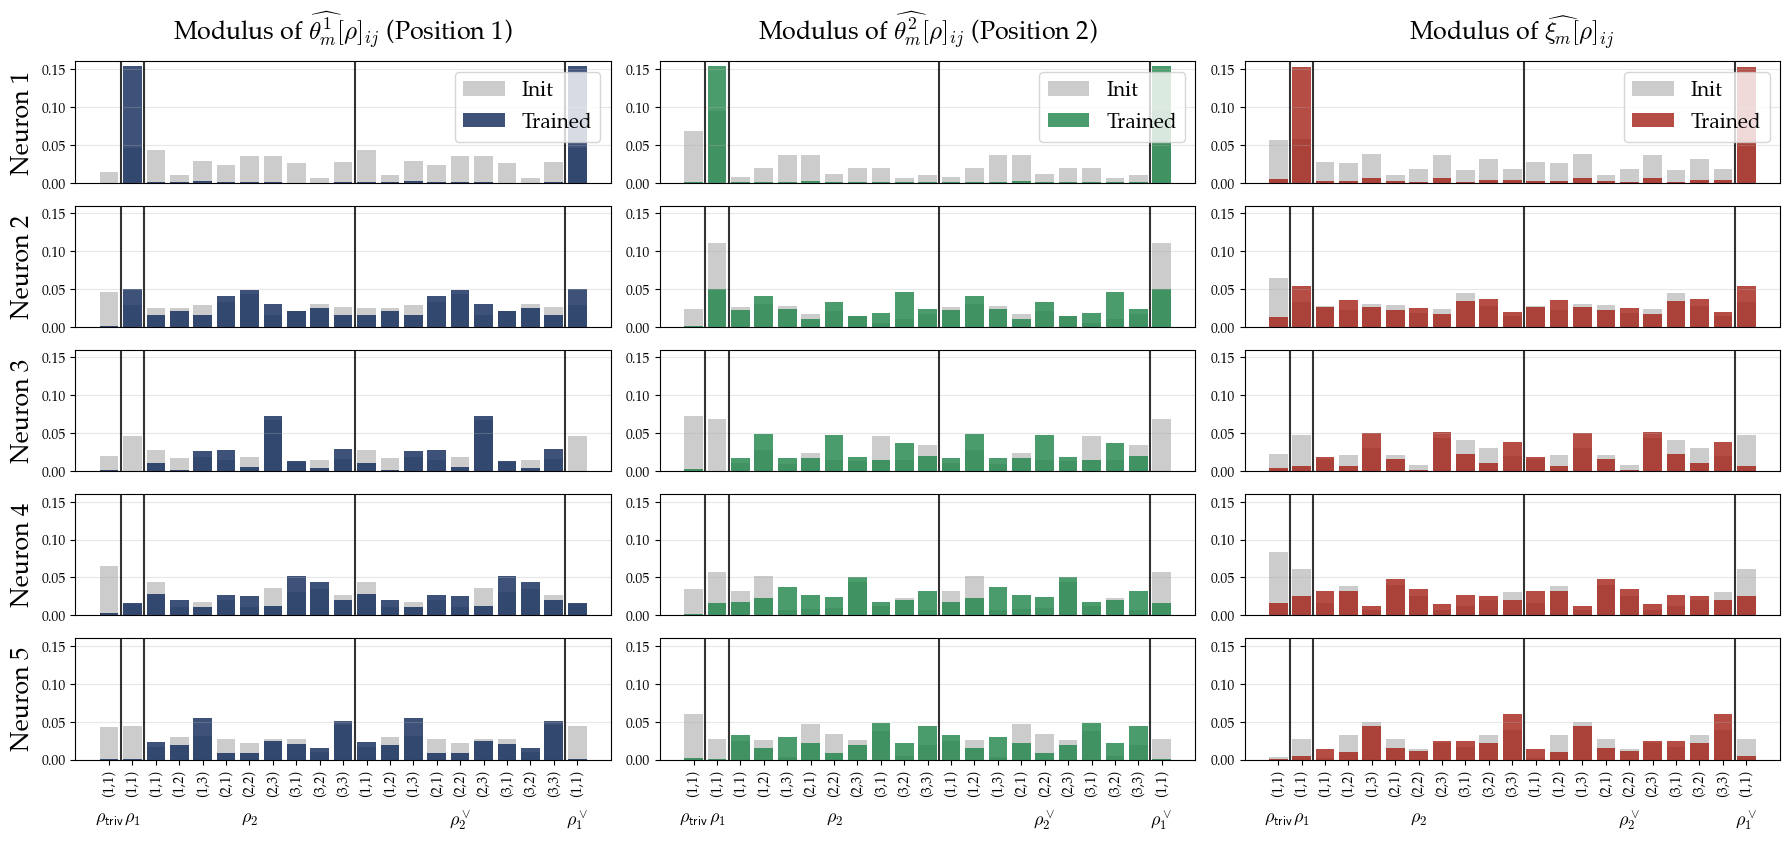

In [263]:
vline_positions = [start - 0.5 for start, _ in irrep_boundaries if start > 0]
bottom_annotations = [(center, FROBENIUS21_IRREP_LATEX[lbl])
                      for center, lbl in zip(irrep_centers, basis.irrep_labels)]

fig = plot_dft_bars(
    [W_in_init_pos1_mag, W_in_init_pos2_mag, W_out_init_mag],
    [W_in_pos1_mag, W_in_pos2_mag, W_out_mag],
    ['#0D2758', '#1E8449', '#A32015'],
    [r'Modulus of $\widehat{\theta_m^1}[\rho]_{ij}$ (Position 1)',
     r'Modulus of $\widehat{\theta_m^2}[\rho]_{ij}$ (Position 2)',
     r'Modulus of $\widehat{\xi_m}[\rho]_{ij}$'],
    basis_labels,
    vline_positions=vline_positions,
    bottom_annotations=bottom_annotations,
    num_neurons=5, ylim=0.16,
)
plt.show()

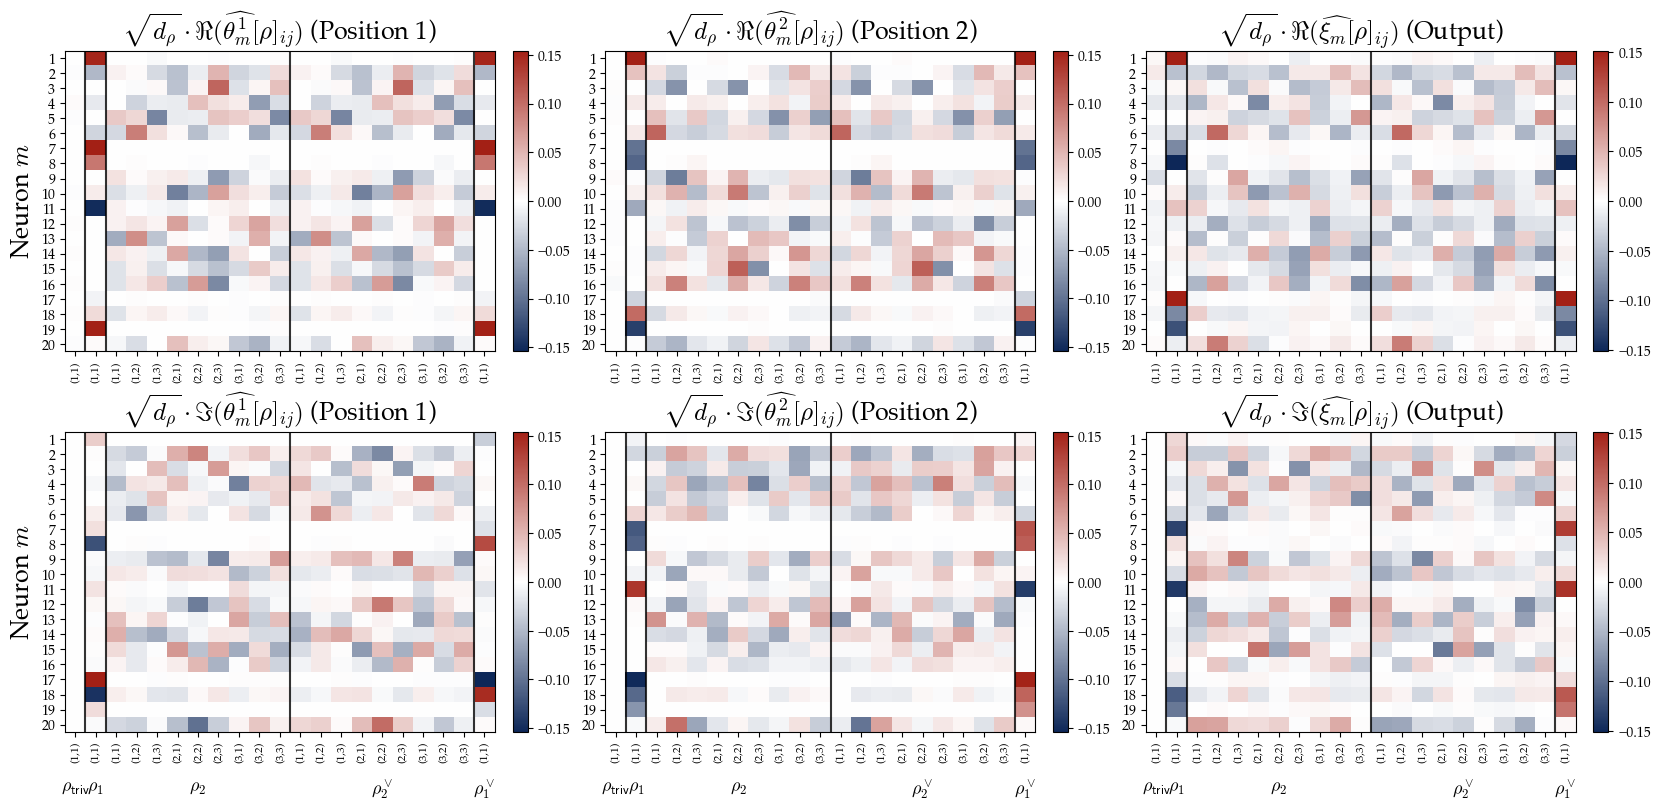

In [264]:
num_components = 20

W1s = scale_by_sqrt_d(W_in_pos1_dft[:num_components], basis)
W2s = scale_by_sqrt_d(W_in_pos2_dft[:num_components], basis)
Wos = scale_by_sqrt_d(W_out_dft[:num_components], basis)

bottom_annotations = [(center, FROBENIUS21_IRREP_LATEX[lbl])
                      for center, lbl in zip(irrep_centers, basis.irrep_labels)]

fig = plot_dft_heatmap(
    [W1s, W2s, Wos],
    [r'$\sqrt{d_\rho}\cdot\Re(\widehat{\theta_m^1}[\rho]_{ij})$ (Position 1)',
     r'$\sqrt{d_\rho}\cdot\Re(\widehat{\theta_m^2}[\rho]_{ij})$ (Position 2)',
     r'$\sqrt{d_\rho}\cdot\Re(\widehat{\xi_m}[\rho]_{ij})$ (Output)'],
    [r'$\sqrt{d_\rho}\cdot\Im(\widehat{\theta_m^1}[\rho]_{ij})$ (Position 1)',
     r'$\sqrt{d_\rho}\cdot\Im(\widehat{\theta_m^2}[\rho]_{ij})$ (Position 2)',
     r'$\sqrt{d_\rho}\cdot\Im(\widehat{\xi_m}[\rho]_{ij})$ (Output)'],
    basis_labels,
    vline_positions=vline_positions,
    bottom_annotations=bottom_annotations,
    cmap=blue_white_red,
)
plt.show()

In [265]:
# Extract per-irrep (d_ρ × d_ρ) matrices for each position and output
W_in_pos1_matrices = extract_irrep_matrices(W_in_pos1_dft.numpy(), basis.irrep_labels, basis.irrep_dimensions)
W_in_pos2_matrices = extract_irrep_matrices(W_in_pos2_dft.numpy(), basis.irrep_labels, basis.irrep_dimensions)
W_out_matrices     = extract_irrep_matrices(W_out_dft.numpy(),     basis.irrep_labels, basis.irrep_dimensions)

for label, mat in W_in_pos1_matrices.items():
    d = basis.irrep_dimensions[label]
    print(f"  {label}: shape = {mat.shape}  ({WIDTH} neurons × {d} × {d})")

  trivial: shape = (512, 1, 1)  (512 neurons × 1 × 1)
  omega: shape = (512, 1, 1)  (512 neurons × 1 × 1)
  rho_3: shape = (512, 3, 3)  (512 neurons × 3 × 3)
  rho_3_conj: shape = (512, 3, 3)  (512 neurons × 3 × 3)
  omega_conj: shape = (512, 1, 1)  (512 neurons × 1 × 1)


/var/folders/5n/bjfmhydx1099fm08r1bdw9br0000gn/T/ipykernel_12128/2028182970.py:82: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_plot = cm.get_cmap("plasma")


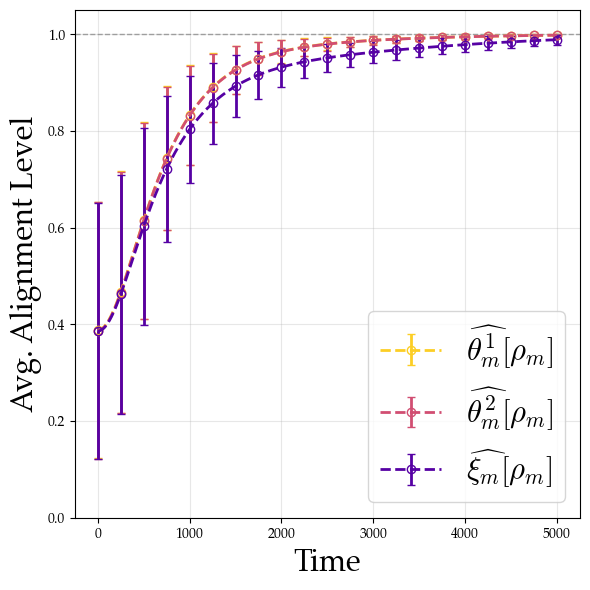

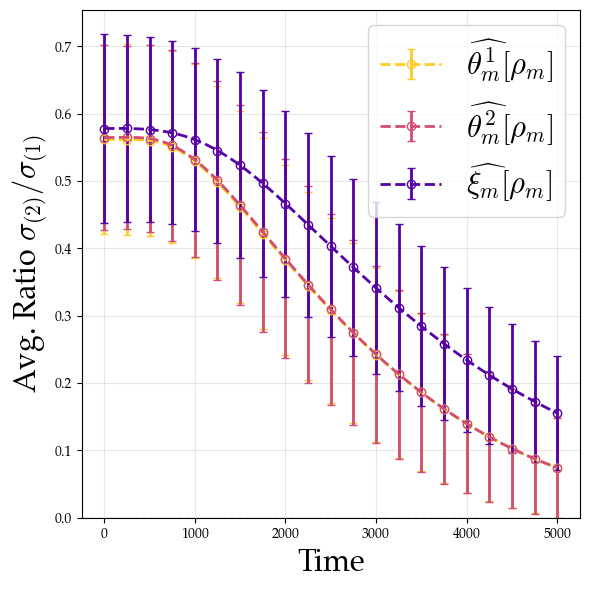

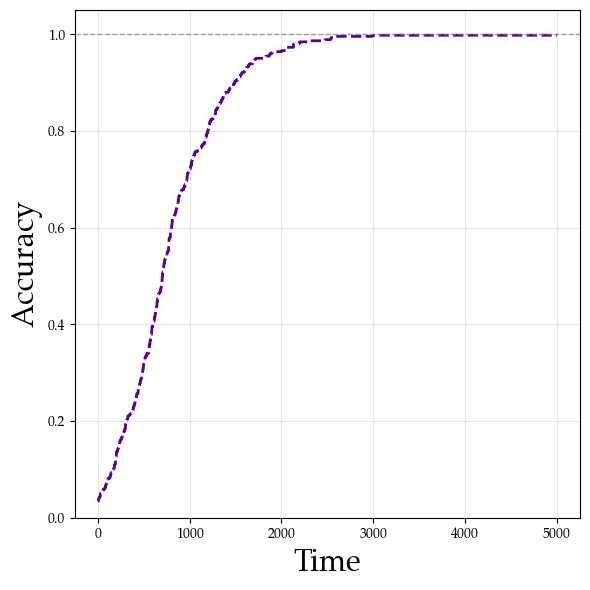

Final metrics at epoch 10000:
Alignment (mean +/- std):
  Cond 1: 0.9886 +/- 0.0104
  Cond 2: 0.9979 +/- 0.0031
  Cond 3: 0.9979 +/- 0.0032
Rank-1 ratio sigma2/sigma1 (d > 1 irreps):
  theta1: 0.073993 +/- 0.073946
  theta2: 0.073986 +/- 0.074133
  xi:     0.155056 +/- 0.084162
Non-trivial neurons: 512
Neurons with d > 1 irreps: 451


In [266]:
# Plot all metrics throughout training
# Uses alignment_history_all, grouped_energy_history_theta1/theta2/xi, rank1_history from cell-8

# === CONFIGURABLE: Set end epoch for plotting (None = plot all) ===
END_EPOCH = 80000  # e.g., 200, 500, or None for full training

# Convert to arrays
epochs_arr = np.array(epochs_tracked)
time_arr = epochs_arr * LR  # x-axis: epoch * lr
n_epochs = len(epochs_tracked)
n_neurons = grouped_energy_history_theta1[-1].shape[0]

# Filter to end epoch if specified
if END_EPOCH is not None:
    epoch_mask = epochs_arr <= END_EPOCH
    epochs_arr = epochs_arr[epoch_mask]
    time_arr = time_arr[epoch_mask]
    n_epochs = len(epochs_arr)

# Determine final dominant irrep (non-grouped) for alignment and rank-1 plots
final_energy_theta1 = grouped_energy_history_theta1[-1]
final_dominant_irreps = []
for m in range(n_neurons):
    dom_idx = np.argmax(final_energy_theta1[m])
    final_dominant_irreps.append(grouped_labels_cache[dom_idx])

# ============ COMPUTE ALIGNMENT METRICS ============
cond1_per_epoch, cond2_per_epoch, cond3_per_epoch = [], [], []
for t in range(n_epochs):
    c1_vals, c2_vals, c3_vals = [], [], []
    for m in range(n_neurons):
        dom_irrep = final_dominant_irreps[m]
        if dom_irrep == "trivial" or "+" in dom_irrep:
            if "+" in dom_irrep:
                dom_irrep = dom_irrep.split("+")[0]
        if dom_irrep == "trivial":
            continue
        if dom_irrep not in alignment_history_all:
            continue
        c1_vals.append(alignment_history_all[dom_irrep]["cond1"][t][m])
        c2_vals.append(alignment_history_all[dom_irrep]["cond2"][t][m])
        c3_vals.append(alignment_history_all[dom_irrep]["cond3"][t][m])
    cond1_per_epoch.append(c1_vals)
    cond2_per_epoch.append(c2_vals)
    cond3_per_epoch.append(c3_vals)

cond1_mean = np.array([np.mean(c) for c in cond1_per_epoch])
cond1_std = np.array([np.std(c) for c in cond1_per_epoch])
cond2_mean = np.array([np.mean(c) for c in cond2_per_epoch])
cond2_std = np.array([np.std(c) for c in cond2_per_epoch])
cond3_mean = np.array([np.mean(c) for c in cond3_per_epoch])
cond3_std = np.array([np.std(c) for c in cond3_per_epoch])

# ============ COMPUTE RANK-1 RATIO ============
theta1_sv_per_epoch, theta2_sv_per_epoch, xi_sv_per_epoch = [], [], []
for t in range(n_epochs):
    t1_vals, t2_vals, xi_vals = [], [], []
    for m in range(n_neurons):
        dom_irrep = final_dominant_irreps[m]
        if "+" in dom_irrep:
            dom_irrep = dom_irrep.split("+")[0]
        if dom_irrep == "trivial":
            continue
        if dom_irrep not in rank1_history:
            continue
        t1_vals.append(rank1_history[dom_irrep]["theta1"][t][m])
        t2_vals.append(rank1_history[dom_irrep]["theta2"][t][m])
        xi_vals.append(rank1_history[dom_irrep]["xi"][t][m])
    theta1_sv_per_epoch.append(t1_vals)
    theta2_sv_per_epoch.append(t2_vals)
    xi_sv_per_epoch.append(xi_vals)

theta1_sv_mean = np.array([np.mean(v) for v in theta1_sv_per_epoch])
theta1_sv_std = np.array([np.std(v) for v in theta1_sv_per_epoch])
theta2_sv_mean = np.array([np.mean(v) for v in theta2_sv_per_epoch])
theta2_sv_std = np.array([np.std(v) for v in theta2_sv_per_epoch])
xi_sv_mean = np.array([np.mean(v) for v in xi_sv_per_epoch])
xi_sv_std = np.array([np.std(v) for v in xi_sv_per_epoch])

# ============ SHARED COLOR SETUP (plasma colormap, 3 lines) ============
import matplotlib.cm as cm
cmap_plot = cm.get_cmap("plasma")
plot_colors = [cmap_plot(0.90 - 0.375 * i) for i in range(3)]  # purple -> teal -> yellow
err_every = max(1, len(time_arr) // 20)  # ~20 error bars across the x-axis
mark_every = max(1, len(time_arr) // 20)  # markers at same cadence

# ============ PLOT 1: Alignment metrics (order: cond2, cond3, cond1) ============
fig1, ax = plt.subplots(figsize=(6, 6))
plot1_data = [
    (cond2_mean, cond2_std, r'$\widehat{\theta^1_m}[\rho_m]$'),
    (cond3_mean, cond3_std, r'$\widehat{\theta^2_m}[\rho_m]$'),
    (cond1_mean, cond1_std, r'$\widehat{\xi_m}[\rho_m]$'),
]
for i, (mean, std, label) in enumerate(plot1_data):
    ax.errorbar(time_arr, mean, yerr=std, color=plot_colors[i], linewidth=2,
                linestyle="--", marker="o", markersize=6, markevery=mark_every, markerfacecolor="none",
                capsize=3, capthick=1, errorevery=err_every, label=label)
ax.set_xlabel(r"Time", fontsize=22)
ax.set_ylabel(r'Avg. Alignment Level', fontsize=22)
ax.set_ylim(0, 1.05)
ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.legend(fontsize=22, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/frobenius21_alignment.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

# ============ PLOT 2: Rank-1 ratio ============
fig2, ax = plt.subplots(figsize=(6, 6))
labels_sv = [
    r'$\widehat{\theta^1_m}[\rho_m]$',
    r'$\widehat{\theta^2_m}[\rho_m]$',
    r'$\widehat{\xi_m}[\rho_m]$',
]
for i, (mean, std) in enumerate([
    (theta1_sv_mean, theta1_sv_std),
    (theta2_sv_mean, theta2_sv_std),
    (xi_sv_mean, xi_sv_std)
]):
    ax.errorbar(time_arr, mean, yerr=std, color=plot_colors[i], linewidth=2,
                linestyle="--", marker="o", markersize=6, markevery=mark_every, markerfacecolor="none",
                capsize=3, capthick=1, errorevery=err_every, label=labels_sv[i])
ax.set_xlabel(r"Time", fontsize=22)
ax.set_ylabel(r'Avg. Ratio $\sigma_{(2)} / \sigma_{(1)}$', fontsize=22)
ax.set_ylim(0, None)
ax.axhline(y=0.0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.legend(fontsize=22, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/frobenius21_rank1.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

# ============ PLOT 3: Accuracy ============
fig3, ax = plt.subplots(figsize=(6, 6))
acc_arr = np.array(accuracies)
time_acc = np.arange(len(acc_arr)) * LR
if END_EPOCH is not None:
    acc_mask = np.arange(len(acc_arr)) <= END_EPOCH
    time_acc = time_acc[acc_mask]
    acc_arr = acc_arr[acc_mask]
ax.plot(time_acc, acc_arr, color=plot_colors[-1], linewidth=2, linestyle='--')
ax.set_xlabel(r"Time", fontsize=22)
ax.set_ylabel(r"Accuracy", fontsize=22)
ax.set_ylim(0, 1.05)
ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/frobenius21_accuracy.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

print(f"Final metrics at epoch {epochs_arr[-1]}:")
print(f"Alignment (mean +/- std):")
print(f"  Cond 1: {cond1_mean[-1]:.4f} +/- {cond1_std[-1]:.4f}")
print(f"  Cond 2: {cond2_mean[-1]:.4f} +/- {cond2_std[-1]:.4f}")
print(f"  Cond 3: {cond3_mean[-1]:.4f} +/- {cond3_std[-1]:.4f}")
print(f"Rank-1 ratio sigma2/sigma1 (d > 1 irreps):")
print(f"  theta1: {theta1_sv_mean[-1]:.6f} +/- {theta1_sv_std[-1]:.6f}")
print(f"  theta2: {theta2_sv_mean[-1]:.6f} +/- {theta2_sv_std[-1]:.6f}")
print(f"  xi:     {xi_sv_mean[-1]:.6f} +/- {xi_sv_std[-1]:.6f}")
print(f"Non-trivial neurons: {len(cond1_per_epoch[0])}")
print(f"Neurons with d > 1 irreps: {len(theta1_sv_per_epoch[0]) if theta1_sv_per_epoch else 0}")


Selected neurons and their dominant irreps:
  Neuron 1: omega (dim=1)
  Neuron 3: rho_3 (dim=3)
  Neuron 4: rho_3 (dim=3)


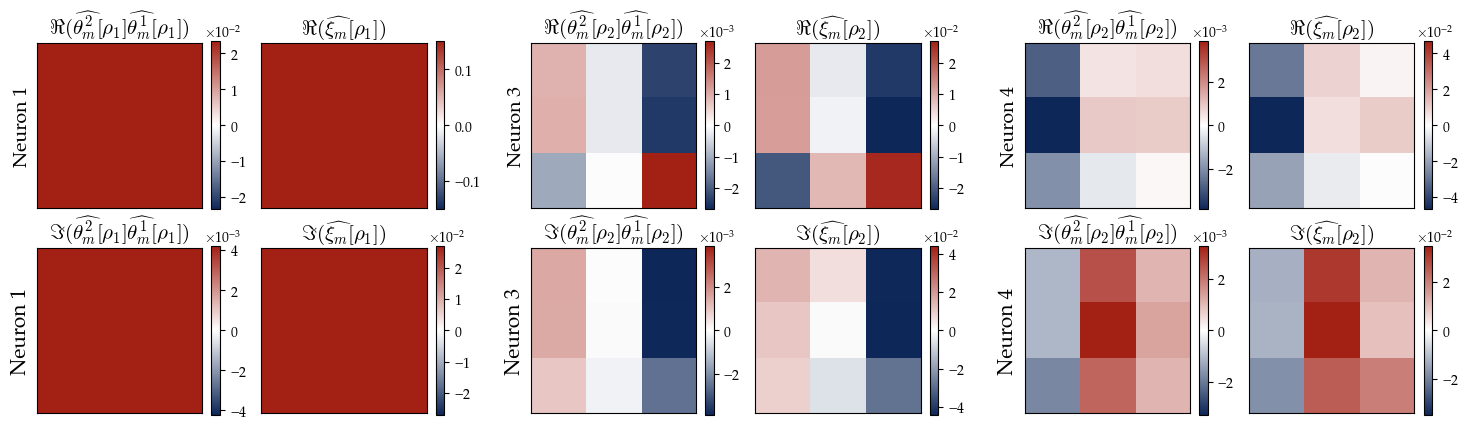


Proportionality check: W2 @ W1 ≈ c · Wout
Neuron     Irrep           Residual        Status         
------------------------------------------------------------
1          omega           0.0000          ✓ Aligned      
3          rho_3           0.1842          ✗ Misaligned   
4          rho_3           0.1505          ✗ Misaligned   


In [267]:
# Compare W2 @ W1 vs Wout for selected neurons
# 2×6 grid: Top row = Real, Bottom row = Imaginary
# Columns alternate: neuron1 product, neuron1 xi, neuron2 product, neuron2 xi, ...
# Automatically detects which irrep each neuron specializes in

from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter

# ============ USER CONFIGURATION ============
# Select neurons by their IDs (0-indexed)
selected_neuron_ids = [0,2,3]  # Just pick any 3 neurons
# ============================================

# LaTeX labels for irreps
irrep_latex = {
    'trivial': r'\rho_{\sf triv}',
    'omega': r'\rho_1',
    'rho_3': r'\rho_2',
    'rho_3_conj': r'\rho_2^\vee',
    'omega_conj': r'\rho_1^\vee',
}

def get_dominant_irrep(neuron_idx):
    """Find which irrep a neuron specializes in (highest energy)."""
    energies = energy_pos1[neuron_idx]
    dominant_idx = np.argmax(energies)
    return basis.irrep_labels[dominant_idx]

def add_colorbar_scientific(fig, im, ax):
    """Add colorbar with scientific notation (10^{-n} scale), offset text moved right."""
    cbar = fig.colorbar(im, ax=ax, fraction=0.046)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.ax.ticklabel_format(style='scientific', scilimits=(-2, 2))
    # Move the exponent label (×10^n) to the right
    cbar.ax.yaxis.get_offset_text().set_x(3.5)
    return cbar

# Detect irrep for each selected neuron
neuron_irreps = [(m, get_dominant_irrep(m)) for m in selected_neuron_ids]
print("Selected neurons and their dominant irreps:")
for m, irrep in neuron_irreps:
    d = basis.irrep_dimensions[irrep]
    print(f"  Neuron {m+1}: {irrep} (dim={d})")

# Create figure with GridSpec for custom spacing
# 8 columns: [n1_prod, n1_xi, gap, n2_prod, n2_xi, gap, n3_prod, n3_xi]
fig = plt.figure(figsize=(18, 5))
gs = GridSpec(2, 8, figure=fig,
              width_ratios=[1, 1, 0.02, 1, 1, 0.02, 1, 1],
              hspace=0.14, wspace=0.3)

# Map neuron index to actual grid columns (skipping gap columns)
col_map = [(0, 1), (3, 4), (6, 7)]  # (product_col, xi_col) for each neuron

for i, (m, irrep_label) in enumerate(neuron_irreps):
    d = basis.irrep_dimensions[irrep_label]
    rho_tex = irrep_latex.get(irrep_label, irrep_label)

    W1 = W_in_pos1_matrices[irrep_label][m]
    W2 = W_in_pos2_matrices[irrep_label][m]
    Wout = W_out_matrices[irrep_label][m]

    # W2 @ W1 (paper's convention)
    W2_W1 = W2 @ W1

    col_product, col_xi = col_map[i]

    # Top row: Real parts
    # W2@W1 Real - independent colorbar
    ax = fig.add_subplot(gs[0, col_product])
    vmax_w2w1_re = max(np.abs(W2_W1.real).max(), 1e-10)
    im = ax.imshow(W2_W1.real, cmap=blue_white_red, vmin=-vmax_w2w1_re, vmax=vmax_w2w1_re)
    ax.set_title(r'$\Re(\widehat{\theta_m^2}[' + rho_tex + r']\widehat{\theta_m^1}[' + rho_tex + r'])$', fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(f'Neuron {m+1}', fontsize=14)
    add_colorbar_scientific(fig, im, ax)

    # Wout Real - independent colorbar
    ax = fig.add_subplot(gs[0, col_xi])
    vmax_wout_re = max(np.abs(Wout.real).max(), 1e-10)
    im = ax.imshow(Wout.real, cmap=blue_white_red, vmin=-vmax_wout_re, vmax=vmax_wout_re)
    ax.set_title(r'$\Re(\widehat{\xi_m}[' + rho_tex + r'])$', fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    add_colorbar_scientific(fig, im, ax)

    # Bottom row: Imaginary parts
    # W2@W1 Imag - independent colorbar
    ax = fig.add_subplot(gs[1, col_product])
    vmax_w2w1_im = max(np.abs(W2_W1.imag).max(), 1e-10)
    im = ax.imshow(W2_W1.imag, cmap=blue_white_red, vmin=-vmax_w2w1_im, vmax=vmax_w2w1_im)
    ax.set_title(r'$\Im(\widehat{\theta_m^2}[' + rho_tex + r']\widehat{\theta_m^1}[' + rho_tex + r'])$', fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(f'Neuron {m+1}', fontsize=15)
    add_colorbar_scientific(fig, im, ax)

    # Wout Imag - independent colorbar
    ax = fig.add_subplot(gs[1, col_xi])
    vmax_wout_im = max(np.abs(Wout.imag).max(), 1e-10)
    im = ax.imshow(Wout.imag, cmap=blue_white_red, vmin=-vmax_wout_im, vmax=vmax_wout_im)
    ax.set_title(r'$\Im(\widehat{\xi_m}[' + rho_tex + r'])$', fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    add_colorbar_scientific(fig, im, ax)

plt.savefig('../figures/frobenius21_fourier_product.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

# Summary table
print("\nProportionality check: W2 @ W1 ≈ c · Wout")
print("=" * 60)
print(f"{'Neuron':<10} {'Irrep':<15} {'Residual':<15} {'Status':<15}")
print("-" * 60)
for m, irrep_label in neuron_irreps:
    W1 = W_in_pos1_matrices[irrep_label][m]
    W2 = W_in_pos2_matrices[irrep_label][m]
    Wout = W_out_matrices[irrep_label][m]

    W2_W1 = W2 @ W1
    W2_W1_norm = W2_W1 / (np.linalg.norm(W2_W1, 'fro') + 1e-10)
    Wout_norm = Wout / (np.linalg.norm(Wout, 'fro') + 1e-10)
    residual = np.linalg.norm(W2_W1_norm - Wout_norm, 'fro')
    status = "✓ Aligned" if residual < 0.1 else "✗ Misaligned"

    print(f"{m+1:<10} {irrep_label:<15} {residual:<15.4f} {status:<15}")

In [268]:
# Check if θ̂₁, θ̂₂, ξ̂ matrices are rank-1 for ALL neurons
# A rank-1 matrix M can be written as M = u @ v^H (outer product)
# We check this by looking at singular values: σ₁ >> σ₂ ≈ ... ≈ σ_d ≈ 0
#
# Note: Singular values (from SVD) are ALWAYS real and non-negative, even for complex matrices.
#       Eigenvalues can be complex. For rank-1 check, we use singular values.

RANK1_THRESHOLD = 0.1  # σ₂/σ₁ < threshold means rank-1

# Collect statistics for all neurons
rank1_stats = {'θ̂₁': {'rank1': 0, 'total': 0, 'ratios': []},
               'θ̂₂': {'rank1': 0, 'total': 0, 'ratios': []},
               'ξ̂': {'rank1': 0, 'total': 0, 'ratios': []}}

all_neuron_data = []  # Store data for all neurons

for m in range(M):
    # Find dominant irrep for this neuron
    energies = energy_pos1[m]
    dom_idx = np.argmax(energies)
    irrep_label = basis.irrep_labels[dom_idx]
    d = basis.irrep_dimensions[irrep_label]
    
    W1 = W_in_pos1_matrices[irrep_label][m]
    W2 = W_in_pos2_matrices[irrep_label][m]
    Wout = W_out_matrices[irrep_label][m]
    
    neuron_info = {'m': m, 'irrep': irrep_label, 'd': d}
    
    for name, mat in [('θ̂₁', W1), ('θ̂₂', W2), ('ξ̂', Wout)]:
        singular_values = np.linalg.svd(mat, compute_uv=False)
        sigma1 = singular_values[0]
        sigma2 = singular_values[1] if len(singular_values) > 1 else 0
        ratio = sigma2 / sigma1 if sigma1 > 1e-10 else np.inf
        
        neuron_info[f'{name}_σ1'] = sigma1
        neuron_info[f'{name}_σ2'] = sigma2
        neuron_info[f'{name}_ratio'] = ratio
        neuron_info[f'{name}_rank1'] = ratio < RANK1_THRESHOLD
        
        # Also compute eigenvalues (can be complex)
        eigenvalues = np.linalg.eigvals(mat)
        neuron_info[f'{name}_eigs'] = eigenvalues
        
        # Only count d > 1 for statistics
        if d > 1:
            rank1_stats[name]['total'] += 1
            rank1_stats[name]['ratios'].append(ratio)
            if ratio < RANK1_THRESHOLD:
                rank1_stats[name]['rank1'] += 1
    
    all_neuron_data.append(neuron_info)

# Summary statistics
print("Rank-1 check for Fourier coefficient matrices (ALL neurons)")
print("=" * 80)
print("\nNote: We use SINGULAR VALUES (always real ≥ 0) for rank check, not eigenvalues.")
print("      Eigenvalues of complex matrices can be complex.")
print(f"\nSummary (d > 1 irreps only, threshold σ₂/σ₁ < {RANK1_THRESHOLD}):")
print("-" * 80)
print(f"{'Matrix':<10} {'Rank-1':<12} {'Total':<12} {'Percentage':<12} {'Mean σ₂/σ₁':<15} {'Max σ₂/σ₁':<15}")
print("-" * 80)
for name, stats in rank1_stats.items():
    pct = 100 * stats['rank1'] / stats['total'] if stats['total'] > 0 else 0
    mean_ratio = np.mean(stats['ratios']) if stats['ratios'] else 0
    max_ratio = np.max(stats['ratios']) if stats['ratios'] else 0
    print(f"{name:<10} {stats['rank1']:<12} {stats['total']:<12} {pct:<12.1f}% {mean_ratio:<15.6f} {max_ratio:<15.6f}")

# Count by irrep type
print("\n" + "=" * 80)
print("Breakdown by irrep type:")
print("-" * 80)

for irrep_label in basis.irrep_labels:
    d = basis.irrep_dimensions[irrep_label]
    if d == 1:
        count = sum(1 for n in all_neuron_data if n['irrep'] == irrep_label)
        print(f"{irrep_label} (d=1): {count} neurons - trivially rank-1")
    else:
        neurons_in_irrep = [n for n in all_neuron_data if n['irrep'] == irrep_label]
        count = len(neurons_in_irrep)
        if count > 0:
            rank1_theta1 = sum(1 for n in neurons_in_irrep if n['θ̂₁_rank1'])
            rank1_theta2 = sum(1 for n in neurons_in_irrep if n['θ̂₂_rank1'])
            rank1_xi = sum(1 for n in neurons_in_irrep if n['ξ̂_rank1'])
            print(f"{irrep_label} (d={d}): {count} neurons")
            print(f"    θ̂₁ rank-1: {rank1_theta1}/{count} ({100*rank1_theta1/count:.1f}%)")
            print(f"    θ̂₂ rank-1: {rank1_theta2}/{count} ({100*rank1_theta2/count:.1f}%)")
            print(f"    ξ̂  rank-1: {rank1_xi}/{count} ({100*rank1_xi/count:.1f}%)")

# Show first 10 neurons with d > 1 irreps in detail (with both singular values and eigenvalues)
print("\n" + "=" * 120)
print("Detailed view (first 10 neurons with d > 1 irreps):")
print("Showing both SINGULAR VALUES (real) and EIGENVALUES (complex)")
print("=" * 120)

count_shown = 0
for n in all_neuron_data:
    if n['d'] == 1:
        continue
    if count_shown >= 10:
        break
    
    print(f"\nNeuron {n['m']+1} ({n['irrep']}, d={n['d']}):")
    print("-" * 100)
    
    for name in ['θ̂₁', 'θ̂₂', 'ξ̂']:
        status = "✓ Rank-1" if n[f'{name}_rank1'] else "✗ Full rank"
        
        # Format singular values
        sv_str = f"σ = [{n[f'{name}_σ1']:.6f}, {n[f'{name}_σ2']:.6f}, ...]"
        
        # Format eigenvalues (complex)
        eigs = n[f'{name}_eigs']
        eig_strs = [f"{e.real:.4f}{'+' if e.imag >= 0 else ''}{e.imag:.4f}j" for e in eigs[:3]]
        eig_str = f"λ = [{', '.join(eig_strs)}]"
        
        print(f"  {name}: {status}")
        print(f"       Singular values (real): {sv_str}  (σ₂/σ₁ = {n[f'{name}_ratio']:.6f})")
        print(f"       Eigenvalues (complex):  {eig_str}")
    
    count_shown += 1

print(f"\n(Showing {count_shown} of {sum(1 for n in all_neuron_data if n['d'] > 1)} neurons with d > 1 irreps)")

Rank-1 check for Fourier coefficient matrices (ALL neurons)

Note: We use SINGULAR VALUES (always real ≥ 0) for rank check, not eigenvalues.
      Eigenvalues of complex matrices can be complex.

Summary (d > 1 irreps only, threshold σ₂/σ₁ < 0.1):
--------------------------------------------------------------------------------
Matrix     Rank-1       Total        Percentage   Mean σ₂/σ₁      Max σ₂/σ₁      
--------------------------------------------------------------------------------
θ̂₁        363          451          80.5        % 0.073993        0.663950       
θ̂₂        362          451          80.3        % 0.073986        0.660783       
ξ̂         100          451          22.2        % 0.155056        0.737133       

Breakdown by irrep type:
--------------------------------------------------------------------------------
trivial (d=1): 0 neurons - trivially rank-1
omega (d=1): 42 neurons - trivially rank-1
rho_3 (d=3): 451 neurons
    θ̂₁ rank-1: 363/451 (80.5%)
    θ̂₂ 

In [269]:
# Compute Ω_m = Σ_{ρ≠1} d_ρ · tr(ξ̂_m[ρ]^H θ̂²_m[ρ] θ̂¹_m[ρ]) for each neuron
# 
# The DFT coefficients are already in paper's L²(G) notation:
#   ν̂[ρ] = (1/|G|) Σ_g ν(g) ρ(g⁻¹)
# So we can directly apply the paper formula.

def compute_omega_m(m):
    """Compute Ω_m for neuron m using paper's DFT coefficients."""
    omega_m = 0.0
    for label in basis.irrep_labels:
        if label == 'trivial':
            continue
        d = basis.irrep_dimensions[label]
        
        # Paper's L²(G) DFT coefficients ν̂[ρ]
        xi_hat = W_out_matrices[label][m]
        theta2_hat = W_in_pos2_matrices[label][m]
        theta1_hat = W_in_pos1_matrices[label][m]
        
        # Paper formula: d_ρ · tr(ξ̂^H @ θ̂² @ θ̂¹)
        product = xi_hat.conj().T @ theta2_hat @ theta1_hat
        omega_m += d * np.trace(product)
    
    return omega_m.real

# Print table
print("Ω_m = Σ_{ρ≠1} d_ρ · tr(ξ̂_m[ρ]^H θ̂²_m[ρ] θ̂¹_m[ρ])")
print("(using paper's L²(G) DFT coefficients)")
print("=" * 40)
print(f"{'Neuron':<10} {'Ω_m':<15}")
print("-" * 40)
for m in range(min(20, M)):  # Show first 20 neurons
    omega_m = compute_omega_m(m)
    print(f"{m+1:<10} {omega_m:<15.6f}")
print("-" * 40)

Ω_m = Σ_{ρ≠1} d_ρ · tr(ξ̂_m[ρ]^H θ̂²_m[ρ] θ̂¹_m[ρ])
(using paper's L²(G) DFT coefficients)
Neuron     Ω_m            
----------------------------------------
1          0.007279       
2          0.003739       
3          0.004143       
4          0.004075       
5          0.004203       
6          0.003982       
7          0.007327       
8          0.007234       
9          0.004167       
10         0.004117       
11         0.006560       
12         0.004187       
13         0.004181       
14         0.004096       
15         0.004171       
16         0.003699       
17         0.007278       
18         0.006179       
19         0.007296       
20         0.004120       
----------------------------------------
